In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import rand_score
import matplotlib.pyplot as plt
import time
import scipy.io

In [2]:
traindata = pd.DataFrame(pd.read_csv("bio_train.dat", sep="\t", header=None))
traindata.dropna()
traindata.drop_duplicates()
traindata = traindata[:10000]

In [3]:
traindata.shape

(10000, 77)

In [4]:
kmeans = KMeans(n_clusters=50, init="k-means++", random_state=42).fit(traindata)
centers = kmeans.cluster_centers_

C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [5]:
def kmeans_cost(data, centers, labels):
    cost = 0.0
    for i in range(len(data)):
        distance = np.linalg.norm(data[i] - centers[labels[i]]) ** 2
        cost += distance
    return cost

In [6]:
cost = kmeans_cost(traindata.values, centers, kmeans.labels_)
optimal_labels = kmeans.labels_
print(f'Cost of KMeans: {cost}')

Cost of KMeans: 20240766450.871975


In [7]:
coreset_size = [500, 1000, 2000, 5000, 7000, 10000]
results = []

probabilities = np.ones(traindata.shape[0])/ traindata.shape[0]
for ssize in coreset_size:
    tic = time.time()
    avg_cost = 0.0
    rand_index = 0.0
    for _ in range(5):
        indices = np.random.choice(traindata.shape[0], size=ssize, replace=False, p=probabilities)
        X_samples = traindata.values[indices]
        kmeans = KMeans(n_clusters= 50, init="k-means++").fit(X_samples)
        labels = kmeans.predict(traindata.values)
        centers = kmeans.cluster_centers_
        avg_cost += kmeans_cost(traindata.values, centers, labels)
        rand_index += rand_score(optimal_labels, labels)
    rand_index /= 5
    avg_cost /= 5
    toc = time.time()
    reduction = ((traindata.shape[0] - X_samples.shape[0])/traindata.shape[0])*100
    error = (abs(avg_cost - cost)/cost)*100
    results.append({'Sampling Type': 'Uniform Sampling',
                        'Coreset Size': X_samples.shape[0],
                        'Average Cost': avg_cost,
                        'Reduction in Data Size': reduction,
                        'Error': error,
                        'Avg Rand Index': rand_index,
                        'Data': 'KDD',
                        'Optimal Cost': cost,
                        'Avg Time': (toc - tic)/5})

C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The defa

In [8]:
results_df = pd.DataFrame(results)
results_df

,Sampling Type,Coreset Size,Average Cost,Reduction in Data Size,Error,Avg Rand Index,Data,Optimal Cost,Avg Time
0,Uniform Sampling,500,5.215751e+10,95.0,157.685452,0.982258,KDD,2.024077e+10,0.384718
1,Uniform Sampling,1000,4.560504e+10,90.0,125.312812,0.985130,KDD,2.024077e+10,0.653296
2,Uniform Sampling,2000,3.890950e+10,80.0,92.233326,0.985803,KDD,2.024077e+10,1.049359
3,Uniform Sampling,5000,2.703307e+10,50.0,33.557545,0.987714,KDD,2.024077e+10,2.104666
4,Uniform Sampling,7000,2.114760e+10,30.0,4.480256,0.989184,KDD,2.024077e+10,2.249459
5,Uniform Sampling,10000,2.040188e+10,0.0,0.795986,0.986729,KDD,2.024077e+10,2.626002


In [9]:
csv_file = 'results.csv'
with open(csv_file, 'a') as f:
    results_df.to_csv(f, header=f.tell()==0, index=False)

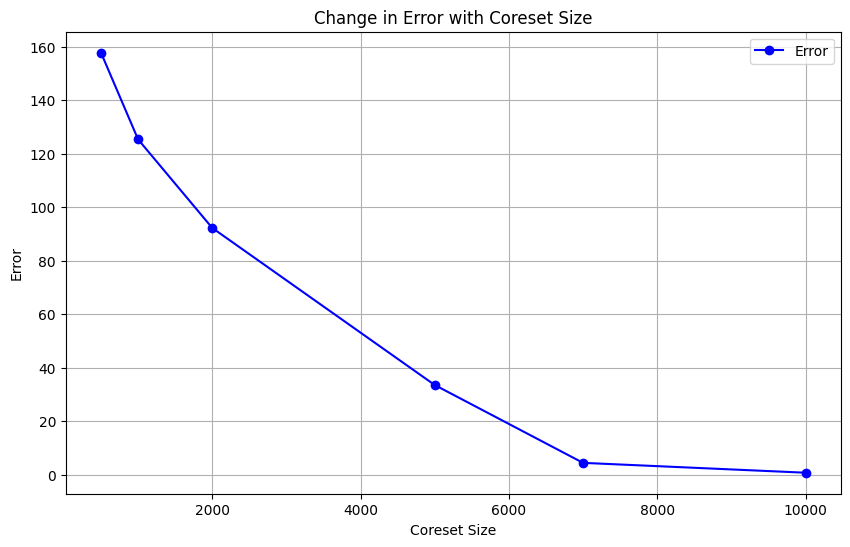

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Error'], marker='o', linestyle='-', color="blue", label="Error")

plt.title('Change in Error with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Error')
plt.legend()
plt.grid(True)
plt.show()

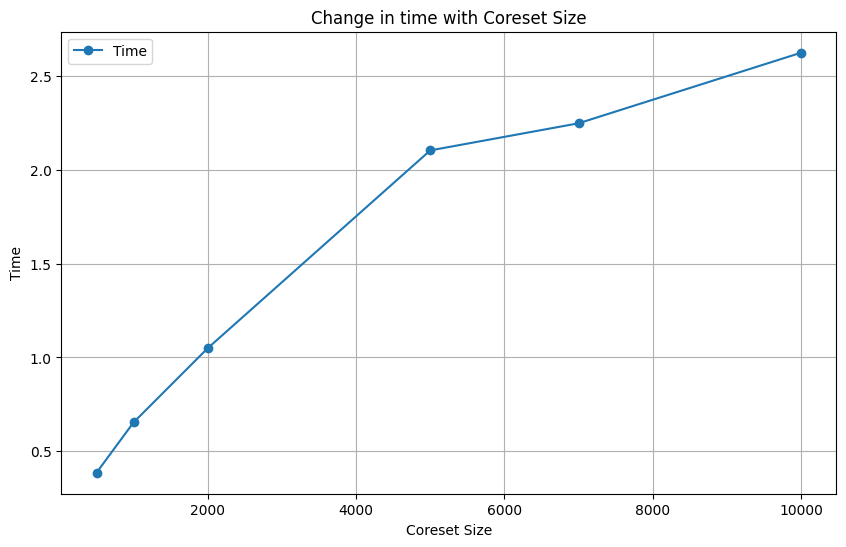

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Avg Time'], marker='o', linestyle='-', label='Time')
plt.legend()
plt.title('Change in time with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Time')
plt.grid(True)
plt.show()

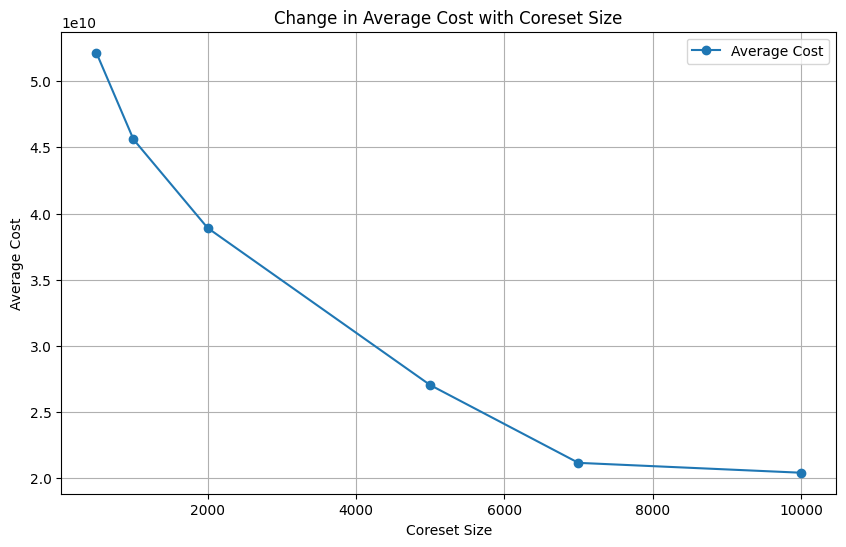

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Average Cost'], marker='o', linestyle='-', label='Average Cost')
plt.legend()
plt.title('Change in Average Cost with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Average Cost')
plt.grid(True)
plt.show()

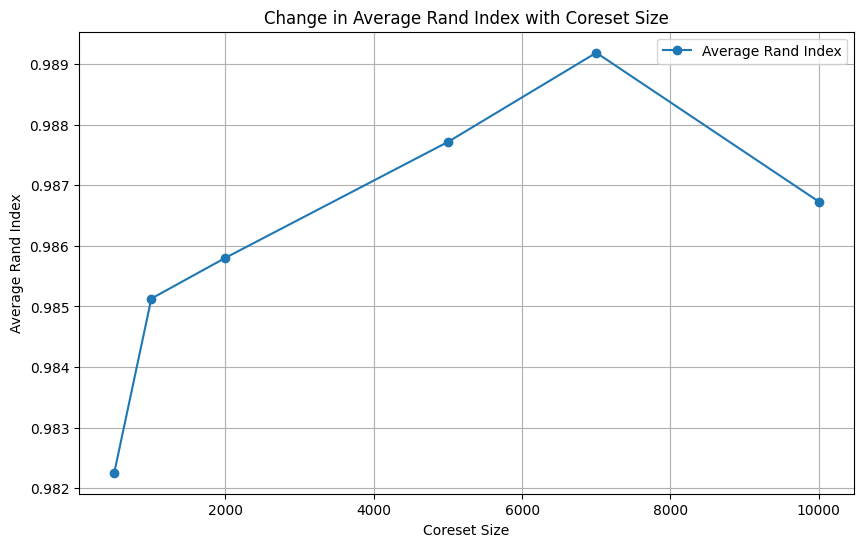

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Avg Rand Index'], marker='o', linestyle='-', label='Average Rand Index')
plt.legend()
plt.title('Change in Average Rand Index with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Average Rand Index')
plt.grid(True)
plt.show()

In [14]:
mat_data = scipy.io.loadmat('olivettifaces.mat')
mat_data['faces'].shape

(4096, 400)

In [15]:
traindata = mat_data['faces'].T
traindata.shape

(400, 4096)

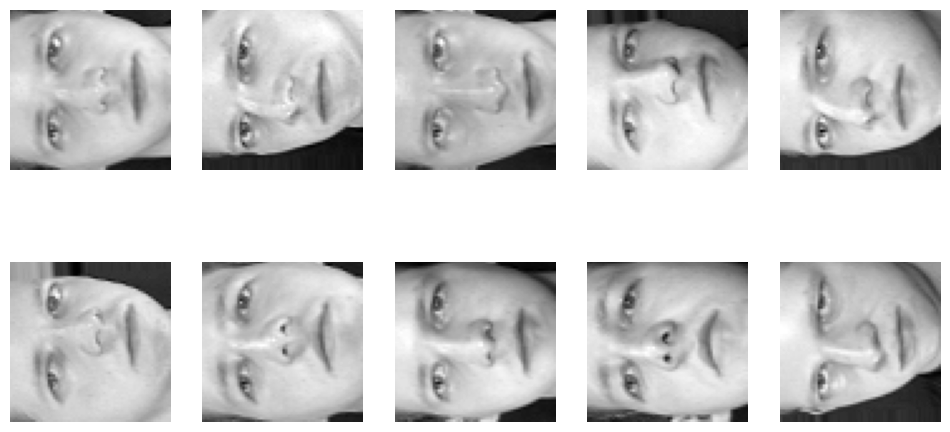

In [16]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(traindata[i].T.reshape(64, 64), cmap='gray')
    ax.axis('off')

plt.show()

In [17]:
traindata = pd.DataFrame(traindata)
traindata.dropna()
traindata.drop_duplicates()
traindata.shape

(400, 4096)

In [18]:
kmeans = KMeans(n_clusters=50, init="k-means++", random_state=42).fit(traindata)
optimal_labels = kmeans.labels_
centers = kmeans.cluster_centers_

C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [19]:
cost = kmeans_cost(traindata.values, centers, optimal_labels)
print(f'Cost of KMeans: {cost}')

Cost of KMeans: 624700740.2474288


In [20]:
coreset_size = [5, 10, 20, 50, 70, 100]
results = []

probabilities = np.ones(traindata.shape[0]) / traindata.shape[0]
for ssize in coreset_size:
    tic = time.time()
    avg_cost = 0.0
    rand_index = 0.0
    for _ in range(5):
        indices = np.random.choice(traindata.shape[0], size=ssize, replace=False, p=probabilities)
        X_samples = traindata.values[indices]
        kmeans = KMeans(n_clusters= 5, init="k-means++").fit(X_samples)
        labels = kmeans.predict(traindata.values)
        centers = kmeans.cluster_centers_
        avg_cost += kmeans_cost(traindata.values, centers, labels)
        rand_index += rand_score(optimal_labels, labels)
    rand_index /= 5
    avg_cost /= 5
    toc = time.time()
    reduction = ((traindata.shape[0] - X_samples.shape[0])/traindata.shape[0])*100
    error = (abs(avg_cost - cost)/cost)*100
    results.append({'Sampling Type': 'Uniform Sampling',
                        'Coreset Size': X_samples.shape[0],
                        'Average Cost': avg_cost,
                        'Reduction in Data Size': reduction,
                        'Error': error,
                        'Avg Rand Index': rand_index,
                        'Data': 'Face',
                        'Optimal Cost': cost,
                        'Avg Time': (toc - tic)/5})

C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\pulki\AppData\Roaming\Python\Python311\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The defa

In [21]:
results_df = pd.DataFrame(results)
results_df

,Sampling Type,Coreset Size,Average Cost,Reduction in Data Size,Error,Avg Rand Index,Data,Optimal Cost,Avg Time
0,Uniform Sampling,5,2.292542e+09,98.75,266.982502,0.671847,Face,6.247007e+08,0.106785
1,Uniform Sampling,10,1.899529e+09,97.50,204.070166,0.699727,Face,6.247007e+08,0.092741
2,Uniform Sampling,20,1.610312e+09,95.00,157.773349,0.715296,Face,6.247007e+08,0.097433
3,Uniform Sampling,50,1.430187e+09,87.50,128.939580,0.703175,Face,6.247007e+08,0.329780
4,Uniform Sampling,70,1.366694e+09,82.50,118.775763,0.783068,Face,6.247007e+08,0.198025
5,Uniform Sampling,100,1.336088e+09,75.00,113.876458,0.768178,Face,6.247007e+08,0.278573


In [22]:
csv_file = 'results.csv'
with open(csv_file, 'a') as f:
    results_df.to_csv(f, header=f.tell()==0, index=False)

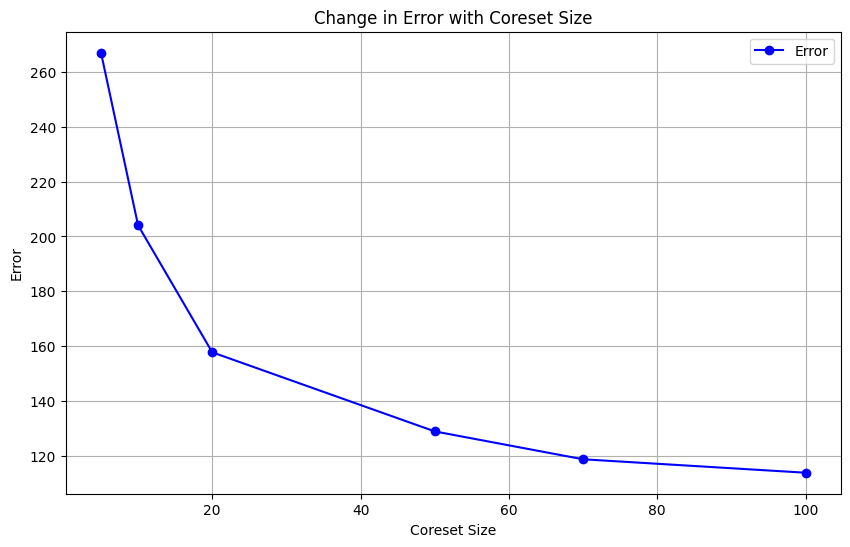

In [23]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Error'], marker='o', linestyle='-', color="blue", label="Error")

plt.title('Change in Error with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Error')
plt.legend()
plt.grid(True)
plt.show()

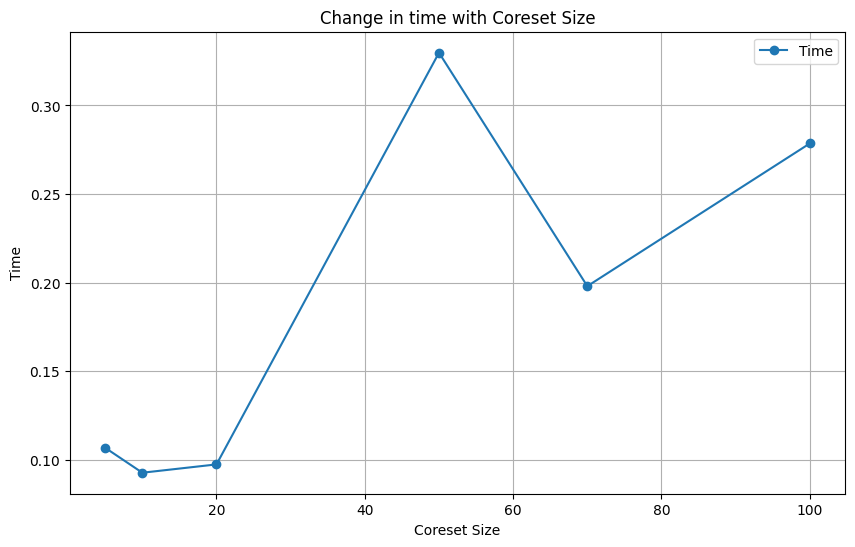

In [24]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Avg Time'], marker='o', linestyle='-', label='Time')
plt.legend()
plt.title('Change in time with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Time')
plt.grid(True)
plt.show()

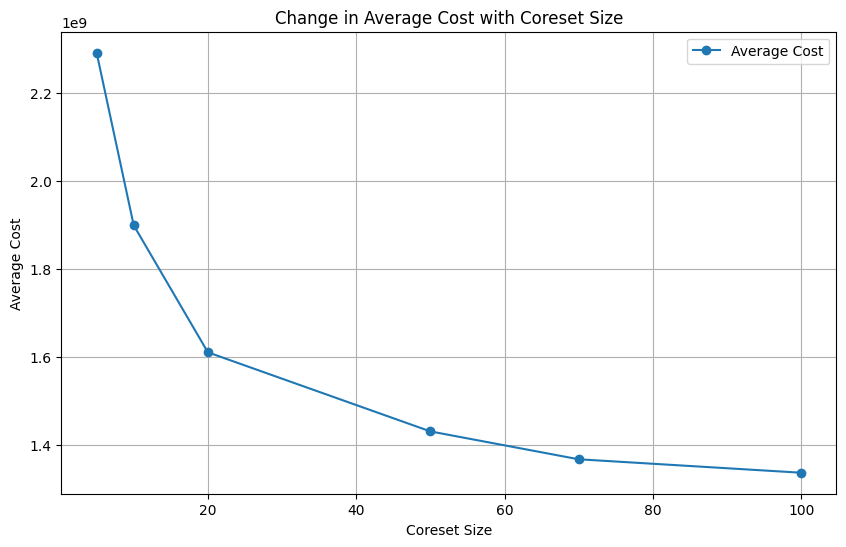

In [25]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Average Cost'], marker='o', linestyle='-', label='Average Cost')
plt.legend()
plt.title('Change in Average Cost with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Average Cost')
plt.grid(True)
plt.show()

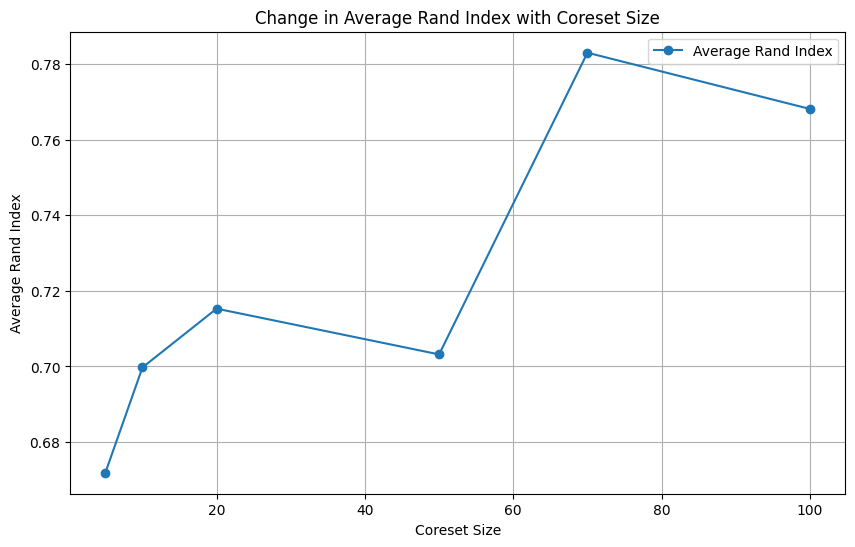

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(results_df['Coreset Size'], results_df['Avg Rand Index'], marker='o', linestyle='-', label='Average Rand Index')
plt.legend()
plt.title('Change in Average Rand Index with Coreset Size')
plt.xlabel('Coreset Size')
plt.ylabel('Average Rand Index')
plt.grid(True)
plt.show()